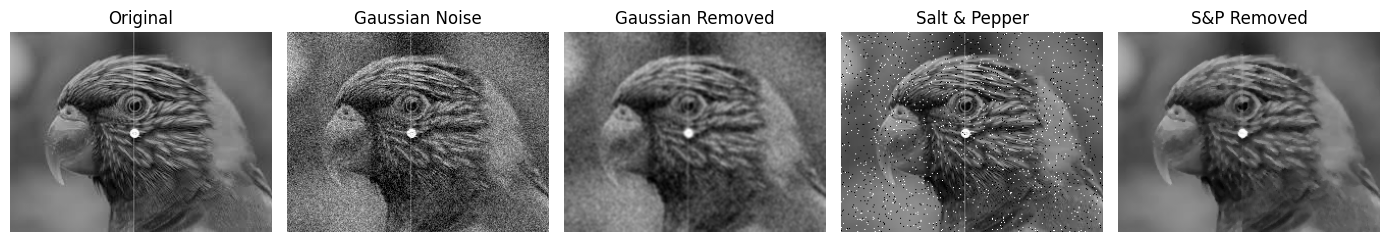

In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/image.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- Add Gaussian noise (simulates sensor electronic noise) ---
gauss_noise = np.random.normal(0, 25, gray.shape).astype(np.float32)
noisy_gauss = np.clip(gray.astype(np.float32) + gauss_noise, 0, 255).astype(np.uint8)

# --- Add salt-and-pepper noise (simulates transmission errors) ---
sp_img = gray.copy()
total_pixels = gray.size
num_salt = int(0.02 * total_pixels)   # 2% salt (white dots)
num_pepper = int(0.02 * total_pixels) # 2% pepper (black dots)

salt_coords = [np.random.randint(0, i, num_salt) for i in gray.shape]
sp_img[salt_coords[0], salt_coords[1]] = 255   # white pixels

pepper_coords = [np.random.randint(0, i, num_pepper) for i in gray.shape]
sp_img[pepper_coords[0], pepper_coords[1]] = 0    # black pixels

# --- Apply Gaussian blur to reduce Gaussian noise ---
denoised_gauss = cv2.GaussianBlur(noisy_gauss, (5, 5), 0)

# --- Apply Median filter to remove salt-and-pepper ---
denoised_sp = cv2.medianBlur(sp_img, 3)

# --- Display results ---
plt.figure(figsize=(14, 5))
for i, (im, title) in enumerate([
    (gray, 'Original'), (noisy_gauss, 'Gaussian Noise'),
    (denoised_gauss, 'Gaussian Removed'), (sp_img, 'Salt & Pepper'),
    (denoised_sp, 'S&P Removed')]):
    plt.subplot(1, 5, i+1); plt.imshow(im, cmap='gray')
    plt.title(title); plt.axis('off')
plt.tight_layout(); plt.show()

In [7]:

# import cv2

# cap = cv2.VideoCapture(0)

# while True:
#     ret, frame = cap. read()
#     if not ret:
#         break
#     cv2.imshow("Live Camera Feed", frame)
    
#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break

# cap. release()
# cv2.destroyAllWindows()

In [6]:
gray1= cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.imshow("Grayscale Image", gray1)
print("Grayscale image shape:", gray1.shape)
cv2.waitKey(0)
cv2.destroyAllWindows()

Grayscale image shape: (196, 257)
